In [1]:
from tensorflow.keras.datasets import boston_housing

(train_data, train_targets), (test_data, test_targets) = (
    boston_housing.load_data()
)

In [2]:
mean = train_data.mean(axis=0)
std = train_data.std(axis=0)

train_data -= mean
train_data /= std
test_data -= mean
test_data /= std

In [4]:
# === Cell 1: Định nghĩa model thuần TensorFlow (float32) ===
import tensorflow as tf

class MyModel(tf.Module):
    def __init__(self, input_dim, name=None):
        super().__init__(name=name)
        self.w1 = tf.Variable(tf.random.normal([input_dim, 64], stddev=0.05, dtype=tf.float32), trainable=True)
        self.b1 = tf.Variable(tf.zeros([64], dtype=tf.float32), trainable=True)

        self.w2 = tf.Variable(tf.random.normal([64, 64], stddev=0.05, dtype=tf.float32), trainable=True)
        self.b2 = tf.Variable(tf.zeros([64], dtype=tf.float32), trainable=True)

        self.w3 = tf.Variable(tf.random.normal([64, 1], stddev=0.05, dtype=tf.float32), trainable=True)
        self.b3 = tf.Variable(tf.zeros([1], dtype=tf.float32), trainable=True)

    def __call__(self, x):
        # đảm bảo x là float32
        x = tf.cast(x, tf.float32)
        x = tf.nn.relu(tf.matmul(x, self.w1) + self.b1)
        x = tf.nn.relu(tf.matmul(x, self.w2) + self.b2)
        return tf.matmul(x, self.w3) + self.b3

def train_model(model, x_train, y_train, epochs=130, batch_size=16, lr=0.001):
    optimizer = tf.optimizers.RMSprop(learning_rate=lr)
    n = x_train.shape[0]

    # convert & reshape về float32 một lần
    x_train = tf.convert_to_tensor(x_train, dtype=tf.float32)
    y_train = tf.reshape(tf.convert_to_tensor(y_train, dtype=tf.float32), (-1, 1))

    for _ in range(epochs):
        idx = tf.random.shuffle(tf.range(n))
        x_train = tf.gather(x_train, idx)
        y_train = tf.gather(y_train, idx)

        for i in range(0, n, batch_size):
            xb = x_train[i:i+batch_size]
            yb = y_train[i:i+batch_size]
            with tf.GradientTape() as tape:
                pred = model(xb)
                loss = tf.reduce_mean(tf.square(yb - pred))  # MSE
            vars_ = [model.w1, model.b1, model.w2, model.b2, model.w3, model.b3]
            grads = tape.gradient(loss, vars_)
            optimizer.apply_gradients(zip(grads, vars_))

def evaluate_model(model, x_test, y_test):
    x_test = tf.convert_to_tensor(x_test, dtype=tf.float32)
    y_test = tf.reshape(tf.convert_to_tensor(y_test, dtype=tf.float32), (-1, 1))
    pred = model(x_test)
    mse = tf.reduce_mean(tf.square(y_test - pred))
    mae = tf.reduce_mean(tf.abs(y_test - pred))
    return float(mse.numpy()), float(mae.numpy())


In [5]:
# === Cell 2: Train + Evaluate (giữ tham số như bản Keras) ===
model = MyModel(input_dim=train_data.shape[1])
train_model(model, train_data, train_targets, epochs=130, batch_size=16)  # mặc định RMSprop(1e-3)

test_mse_score, test_mae_score = evaluate_model(model, test_data, test_targets)
print("Test MSE:", test_mse_score)
print("Test MAE:", test_mae_score)


Test MSE: 16.083415985107422
Test MAE: 2.599724531173706


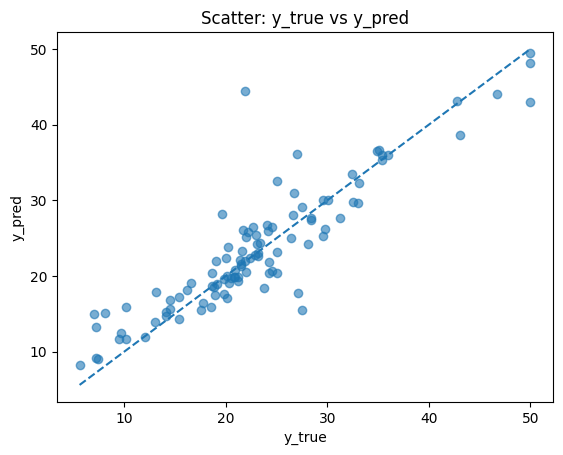

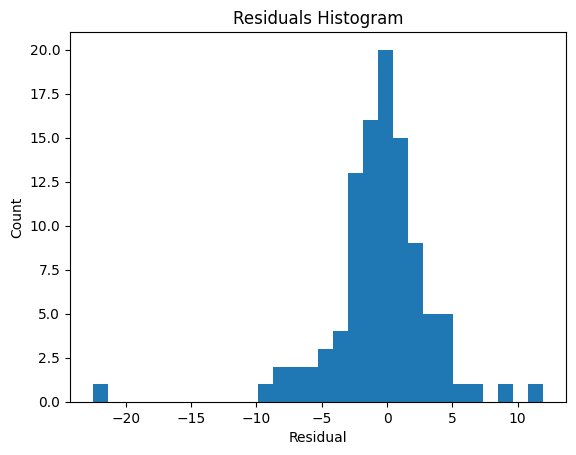

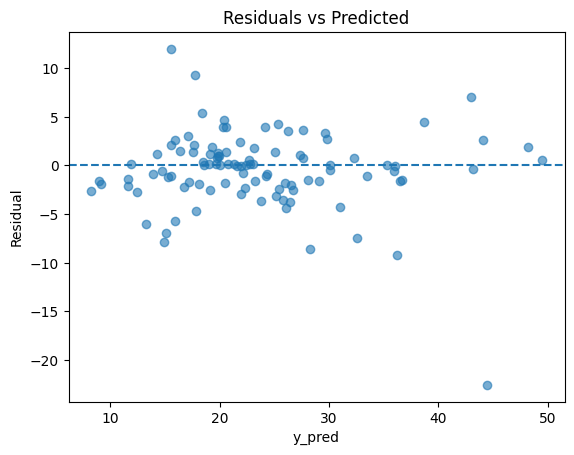

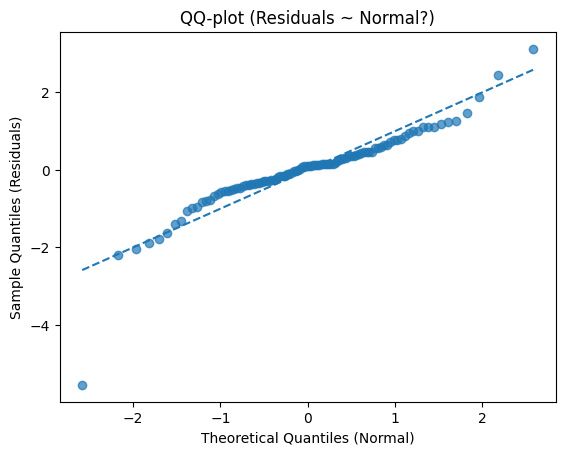

In [6]:
# === Cell 3: Visualize trên tập test ===
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

# 1) Lấy dự đoán và residuals
y_true = np.asarray(test_targets).reshape(-1)
y_pred = np.asarray(model(tf.convert_to_tensor(test_data, dtype=tf.float32)).numpy()).reshape(-1)
residuals = y_true - y_pred

# 2) y_true vs y_pred (đường chéo lý tưởng)
plt.figure()
plt.scatter(y_true, y_pred, alpha=0.6)
min_v, max_v = np.min([y_true, y_pred]), np.max([y_true, y_pred])
plt.plot([min_v, max_v], [min_v, max_v], linestyle="--")
plt.xlabel("y_true")
plt.ylabel("y_pred")
plt.title("Scatter: y_true vs y_pred")
plt.show()

# 3) Histogram residuals
plt.figure()
plt.hist(residuals, bins=30)
plt.xlabel("Residual")
plt.ylabel("Count")
plt.title("Residuals Histogram")
plt.show()

# 4) Residuals vs y_pred
plt.figure()
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("y_pred")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted")
plt.show()

# 5) QQ-plot (xấp xỉ nhanh, không dùng seaborn)
#   Lấy quantiles của residuals và chuẩn hoá so với Normal(0,1)
res_sorted = np.sort((residuals - residuals.mean()) / (residuals.std() + 1e-8))
probs = (np.arange(1, len(res_sorted)+1) - 0.5) / len(res_sorted)
theoretical_q = st.norm.ppf(probs)

plt.figure()
plt.scatter(theoretical_q, res_sorted, alpha=0.7)
plt.plot([theoretical_q.min(), theoretical_q.max()],
         [theoretical_q.min(), theoretical_q.max()], linestyle="--")
plt.xlabel("Theoretical Quantiles (Normal)")
plt.ylabel("Sample Quantiles (Residuals)")
plt.title("QQ-plot (Residuals ~ Normal?)")
plt.show()


In [7]:
# === Cell 4: Nhiều metrics + Baseline so sánh ===
import numpy as np

def metrics_report(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    mse = np.mean((y_true - y_pred)**2)
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(mse)
    # R2: 1 - SS_res / SS_tot (bắt lỗi trường hợp var=0)
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2) + 1e-12
    r2 = 1 - ss_res/ss_tot
    # Tránh chia 0 cho MAPE
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-8))) * 100
    medae = np.median(np.abs(y_true - y_pred))
    return dict(MSE=mse, MAE=mae, RMSE=rmse, R2=r2, MAPE_pct=mape, MedianAE=medae)

# Dự đoán của model (đã có ở Cell 3): y_pred
report_model = metrics_report(y_true, y_pred)

# Baseline: luôn đoán = mean(y_train)
y_base = np.full_like(y_true, fill_value=float(np.mean(train_targets)))
report_base = metrics_report(y_true, y_base)

print("=== Metrics (Model) ===")
for k,v in report_model.items():
    print(f"{k}: {v:.6f}")

print("\n=== Metrics (Baseline: predict mean(y_train)) ===")
for k,v in report_base.items():
    print(f"{k}: {v:.6f}")

# Gợi ý diễn giải nhanh theo tiêu chí
def quick_explain(rep_m, rep_b):
    txt = []
    better = lambda m,b: "tốt hơn" if m<b else "kém hơn"
    txt.append(f"- MSE/RMSE: {better(rep_m['MSE'], rep_b['MSE'])} baseline (nhỏ hơn là tốt).")
    txt.append(f"- MAE: {better(rep_m['MAE'], rep_b['MAE'])} baseline (nhỏ hơn là tốt).")
    txt.append(f"- MedianAE: {better(rep_m['MedianAE'], rep_b['MedianAE'])} baseline (chống nhiễu tốt).")
    txt.append(f"- MAPE: {better(rep_m['MAPE_pct'], rep_b['MAPE_pct'])} baseline (nhỏ hơn là tốt, % sai số).")
    txt.append(f"- R²: {'cao hơn' if rep_m['R2']>rep_b['R2'] else 'thấp hơn'} baseline (gần 1 là tốt).")
    return "\n".join(txt)

print("\n=== Giải thích nhanh ===")
print(quick_explain(report_model, report_base))


=== Metrics (Model) ===
MSE: 16.083417
MAE: 2.599725
RMSE: 4.010414
R2: 0.806792
MAPE_pct: 14.328404
MedianAE: 1.810494

=== Metrics (Baseline: predict mean(y_train)) ===
MSE: 83.710859
MAE: 6.533042
RMSE: 9.149364
R2: -0.005610
MAPE_pct: 37.641290
MedianAE: 4.254950

=== Giải thích nhanh ===
- MSE/RMSE: tốt hơn baseline (nhỏ hơn là tốt).
- MAE: tốt hơn baseline (nhỏ hơn là tốt).
- MedianAE: tốt hơn baseline (chống nhiễu tốt).
- MAPE: tốt hơn baseline (nhỏ hơn là tốt, % sai số).
- R²: cao hơn baseline (gần 1 là tốt).
